## Forecasting Campus Parking: Main Code File
Sophia Huang and Lydia Wyble   
DATA 580F

**Link to Application:** https://pitch-squad-47294237.figma.site/

### Data Preparation:
Objectives:
1.   Load PKLot data into Colab
2.   Map annotations onto images
3. Prepare initial visualizations



In [1]:
#install and import all packages
!pip install ultralytics
!pip install -U albumentations
import os
import json
import random
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from collections import Counter
import shutil
from ultralytics import YOLO
import yaml
import numpy as np
import pandas as pd
import torch
import datetime

In [2]:
#mount google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Current model enviroment:
5867 training images, 6010 test images, 539 validation images. Train contains Sept, Oct, Jan, and Apr; test contains Nov, Dec, and Mar (initial plan of spring semester months as the test set is not possible, as this did not contain every lot configuration); validation contains Feb.

In [3]:
#load annotation files
#the annotations contain the image's timestamp, bounding boxes, etc.
def load_json_data(path):
    annotation_file = os.path.join(path, '_annotations_final.coco.json')

    with open(annotation_file, 'r') as file:
        data = json.load(file)
        data['path'] = path
        return data

In [4]:
#set path for each split and set of annotations
path = "/content/drive/MyDrive/580F Project/PKLot"
TRAIN_PATH = os.path.join(path, 'train')
VAL_PATH =  os.path.join(path, 'valid')
TEST_PATH = os.path.join(path, 'test')

train_annotations = load_json_data(TRAIN_PATH)
val_annotations = load_json_data(VAL_PATH)
test_annotations = load_json_data(TEST_PATH)

### Initial Visualizations
Objective: Create functions that display data points in different context, for use in verification imaging and later visualizations.

In [5]:
#color coding
CATEGORY_MAPPING = {
    1: {'name': 'space-empty', 'clr': (0, 255, 0)},
    2: {'name': 'space-occupied', 'clr': (0, 0, 255)},
    'default': {'name': 'Other', 'clr': (255, 0, 0)}
}

#use annotations to count empty vs. occupied spaces (input is the json dictionary, not the image)
#i dont think we ever use this
def display_class_distribution(pltk_json_dict):
    pltk_ann = [ann['category_id'] for ann in pltk_json_dict['annotations']]
    counts = Counter(pltk_ann)

    class_names = [CATEGORY_MAPPING[1]['name'], CATEGORY_MAPPING[2]['name']]
    values = [counts[1], counts[2]]

    plt.figure(figsize=(7,5))
    bars = plt.bar(class_names, values, color=['green', 'red'])

    for bar, value in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            value,
            str(value),
            ha='center',
            va='bottom',
        )

    plt.title(f"Dataset: {os.path.basename(pltk_json_dict['path']).capitalize()}", fontsize=14)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

#taking image and the json annotations, draws a bounding box on each parking space
def draw_bbox_on_image(image_info, pltk_json_dict, image):
    image_annotations = [
        anno for anno in pltk_json_dict['annotations']
        if anno['image_id'] == image_info['id']
    ]

    empty_count = 0
    occupied_count = 0

    # draw boxes + count per category
    for annotation in image_annotations:
        category_id = annotation['category_id']
        bbox = annotation['bbox']

        x, y, w, h = map(int, bbox)
        category_data = CATEGORY_MAPPING.get(category_id, CATEGORY_MAPPING['default'])
        color = category_data['clr']

        if category_id == 1:
            empty_count += 1
        elif category_id == 2:
            occupied_count += 1

        cv2.rectangle(image, (x, y), (x + w, y + h), color, 2)

    #prepare image and text box
    overlay = image.copy()
    x1, y1 = 5, 5
    x2, y2 = 260, 80

    cv2.rectangle(overlay, (x1, y1), (x2, y2), (0, 0, 0), thickness=-1)
    alpha = 0.6
    image = cv2.addWeighted(overlay, alpha, image, 1 - alpha, 0)

    cv2.putText(
        image,
        f"Empty: {empty_count}",
        (x1 + 10, y1 + 25),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 255, 255),
        2,
        cv2.LINE_AA,
    )

    cv2.putText(
        image,
        f"Occupied: {occupied_count}",
        (x1 + 10, y1 + 55),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 255, 255),
        2,
        cv2.LINE_AA,
    )

    return image

#uses the above function to display a single image with annotations
def display_image(image_info, pltk_json_dict, ax):
    image_path = os.path.join(pltk_json_dict['path'], image_info['file_name'])
    image = cv2.imread(image_path)

    if image is None:
        return None

    image_with_bbox = draw_bbox_on_image(image_info, pltk_json_dict, image)
    display_image = cv2.cvtColor(image_with_bbox, cv2.COLOR_BGR2RGB)

    ax.imshow(display_image)
    ax.axis("off")

# same as the above function, lays out several images (works best with 3)
def display_multiple_random_images(pltk_json_dict, num_images=3):
    all_images = pltk_json_dict['images']
    selected_images = random.sample(all_images, num_images)

    rows = 1
    cols = num_images

    fig, axes = plt.subplots(rows, cols, figsize=(12, 8))
    axes = axes.flatten()

    for i, image_info in enumerate(selected_images):
         display_image(image_info, pltk_json_dict, axes[i])

    legend_handles = [
        Patch(
            facecolor=(v['clr'][2]/255., v['clr'][1]/255., v['clr'][0]/255.),
            label=v['name']
        )
        for k, v in CATEGORY_MAPPING.items() if k != 'default'
    ]

    fig.legend(handles=legend_handles, ncol=len(legend_handles), loc='upper center',bbox_to_anchor=(0.5, 0.8))
    fig.suptitle(f"Dataset: {os.path.basename(pltk_json_dict['path']).capitalize()}", y=0.85)
    plt.tight_layout()
    plt.show()

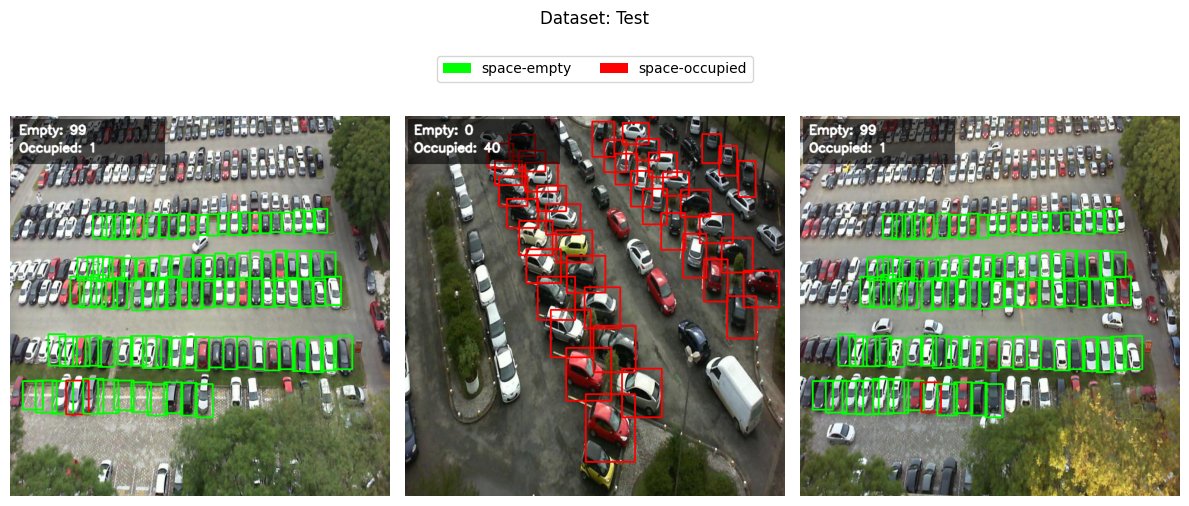

In [6]:
display_multiple_random_images(test_annotations)

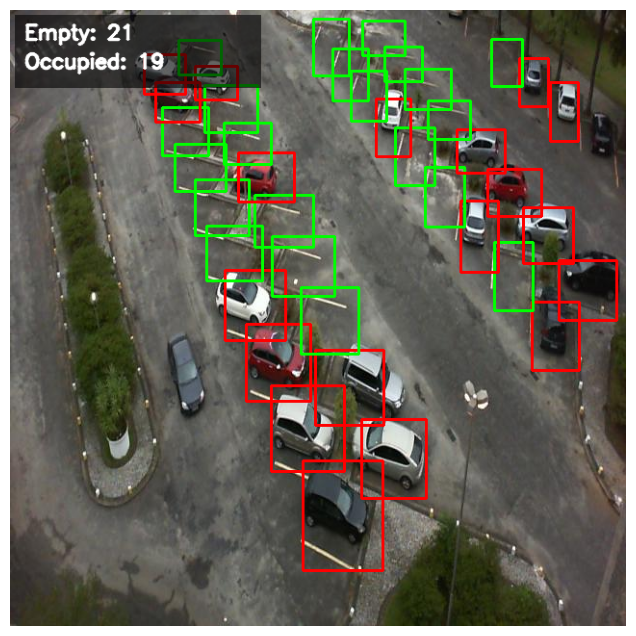

In [19]:
#display an image, based on file path
#image_path = "/content/drive/MyDrive/580F Project/PKLot/test/2012-12-07_20_12_28_jpg.rf.6e26d4070b348e6796a26015a3b93ac7.jpg"
image_filename = os.path.basename(image_path)

#find the image_info dictionary for the specific image from test_annotations
selected_image_info = None
for img_info in test_annotations['images']:
    if img_info['file_name'] == image_filename:
        selected_image_info = img_info
        break

if selected_image_info:
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    display_image(selected_image_info, test_annotations, ax)
    plt.show()
else:
    print(f"Image '{image_filename}' not found in test_annotations.")

### Data Preparation (Continued)

In [6]:
#create final splits with labels and annotated images in a new working folder
#a runtime of 4-7 minutes is expected here

INPUT_ROOT = path
WORKING_ROOT = '/content/working/custom_yolo_data'
COCO_JSON_PATH = os.path.join(INPUT_ROOT, '_annotations_final.coco.json')
CLASSES = ['space-empty', 'space-occupied']


if os.path.exists(WORKING_ROOT):
    shutil.rmtree(WORKING_ROOT)

for split in ['train', 'valid', 'test']:
    source_images_dir = os.path.join(INPUT_ROOT, split)

    target_images_dir = os.path.join(WORKING_ROOT, split, 'images')
    target_labels_dir = os.path.join(WORKING_ROOT, split, 'labels')

    os.makedirs(target_images_dir, exist_ok=True)
    os.makedirs(target_labels_dir, exist_ok=True)
    print(f"Created directories for {split}: {target_images_dir} and {target_labels_dir}")

    if not os.path.exists(source_images_dir):
        continue

    print(f"Copying images from {source_images_dir} to {target_images_dir}...")

    copied_count = 0
    for entry in os.scandir(source_images_dir):
        if entry.is_file() and entry.name.lower().endswith('.jpg'): #('.jpg', '.jpeg', '.png')
            source_file_path = entry.path
            target_file_path = os.path.join(target_images_dir, entry.name)
            shutil.copy2(source_file_path, target_file_path)
            copied_count += 1

    print(f"Finished copying {copied_count} images for the {split} split.")

Created directories for train: /content/working/custom_yolo_data/train/images and /content/working/custom_yolo_data/train/labels
Copying images from /content/drive/MyDrive/580F Project/PKLot/train to /content/working/custom_yolo_data/train/images...
Finished copying 5867 images for the train split.
Created directories for valid: /content/working/custom_yolo_data/valid/images and /content/working/custom_yolo_data/valid/labels
Copying images from /content/drive/MyDrive/580F Project/PKLot/valid to /content/working/custom_yolo_data/valid/images...
Finished copying 539 images for the valid split.
Created directories for test: /content/working/custom_yolo_data/test/images and /content/working/custom_yolo_data/test/labels
Copying images from /content/drive/MyDrive/580F Project/PKLot/test to /content/working/custom_yolo_data/test/images...
Finished copying 6010 images for the test split.


In [7]:
#convert annotations to YOLO-compatible format
def coco_to_yolo_converter_split(split_name, input_root, working_root, class_names):
    coco_json_path = os.path.join(input_root, split_name, '_annotations_final.coco.json')

    labels_dir = os.path.join(working_root, split_name, 'labels')
    images_dir = os.path.join(working_root, split_name, 'images')

    with open(coco_json_path, 'r') as f:
        data = json.load(f)

    category_map = {cat['id']: class_names.index(cat['name']) for cat in data['categories'] if cat['name'] in class_names}
    image_map = {img['id']: {'file_name': img['file_name'], 'width': img['width'], 'height': img['height']} for img in data['images']}

    annotations_by_image = {}
    for ann in data['annotations']:
        img_info = image_map.get(ann['image_id'])
        if not img_info: continue

        img_file = img_info['file_name']
        img_width = img_info['width']
        img_height = img_info['height']

        class_index = category_map.get(ann['category_id'])
        if class_index is None: continue

        x_min, y_min, w_px, h_px = ann['bbox']

        # normalize images
        x_center = (x_min + w_px / 2) / img_width
        y_center = (y_min + h_px / 2) / img_height
        w_norm = w_px / img_width
        h_norm = h_px / img_height

        yolo_line = f"{class_index} {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}"

        if img_file not in annotations_by_image:
            annotations_by_image[img_file] = []
        annotations_by_image[img_file].append(yolo_line)
    total_labels_written = 0
    #print(f"Writing labels for {split_name} split to {labels_dir}")

    for image_file in os.listdir(images_dir):
        base_name, ext = os.path.splitext(image_file)
        if ext.lower() in ('.jpg', '.jpeg'):
            label_file_path = os.path.join(labels_dir, f"{base_name}.txt")

            if image_file in annotations_by_image:
                with open(label_file_path, 'w') as f:
                    f.write('\n'.join(annotations_by_image[image_file]) + '\n')
                total_labels_written += len(annotations_by_image[image_file])
            else:
                with open(label_file_path, 'w') as f: pass

    print(f"[Split: {split_name}] Conversion Complete. Total BBoxes: {total_labels_written}")

In [8]:
#execute the above function for each data split
for split in ['train', 'valid', 'test']:
    coco_to_yolo_converter_split(split, INPUT_ROOT, WORKING_ROOT, CLASSES)

[Split: train] Conversion Complete. Total BBoxes: 434768
[Split: valid] Conversion Complete. Total BBoxes: 21560
[Split: test] Conversion Complete. Total BBoxes: 255528


### Model Training
Objectives:


1.   Train a YOLO26 computer vision algorithm on training data
2.   Report key performance metrics



In [9]:
#create new directory for model results
yaml_content = f"""
path: {WORKING_ROOT}
train: train/images
val: valid/images
test: test/

# Classes
nc: {len(CLASSES)}
names: {CLASSES}
"""
new_yaml_path = os.path.join('/content/working', 'data.yaml')

with open(new_yaml_path, 'w') as f:
    f.write(yaml_content)



In [ ]:
#TRAIN A NEW MODEL
#not necessary if using an existing .pt file

model_yolo = YOLO("yolo26s.pt")
results = model_yolo.train(
    data="/content/working/data.yaml",
    imgsz=480,
    epochs=40,
    patience=10, #model stops if no significant improvement after x passes
    batch=-1, #batch size (number of images in one pass)
    verbose=True
)


Ultralytics 8.4.42 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=480, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, per

In [ ]:
#TUNE A TRAINED MODEL

model_best = YOLO("/content/drive/MyDrive/580F Project/YOLO26/bestS_tuned.pt")

#set tuning parameters
search_space = {
    "lr0": (1e-5, 1e-3),
    "degrees": (0.0, 45.0),
    "scale": (0, 0.5),
    "translate": (0,0.5)
}

#modify epochs and iterations as necessary
model_best.tune(
    data="/content/working/data.yaml",
    epochs=10,
    iterations=10,
    space=search_space,
    plots=False,
    save=False,
    val=False,
    resume = True
)

Tuner: Initialized Tuner instance with 'tune_dir=/content/runs/detect/tune'
Tuner: 💡 Learn about tuning at https://docs.ultralytics.com/guides/hyperparameter-tuning
Tuner: Resuming tuning run /content/runs/detect/tune from iteration 7...
Tuner: Starting iteration 7/10 with hyperparameters: {'lr0': 1e-05, 'degrees': 0.00124, 'scale': 0.47032, 'translate': 0.12287}


In [ ]:
#run best model on test set
#warning: throws errors or makes unnecessary duplicates if this cell is run multiple times
training_files_path = '/content/runs/detect/train'
best_model_path = '/content/drive/MyDrive/580F Project/YOLO26/bestS_tuned.pt'
best_model= YOLO(best_model_path)

In [ ]:
#get performance metrics
metrics_rt_yolo = best_model.val(
    data='/content/working/data.yaml',
    imgsz=480,
    split='test', #choose split
    save_json=True,
    device='cuda' #cuda or cpu
)

TEST_IMAGES_DIR = "/content/working/custom_yolo_data/test/images"
TEST_LABELS_DIR = "/content/working/custom_yolo_data/test/labels"

mAP_50 = metrics_rt_yolo.box.map50
precision = metrics_rt_yolo.box.mp
recall = metrics_rt_yolo.box.mr

print(f"Test Dataset Accuracy Metrics")
print(f"mAP@0.5 (IoU >= 0.5): {mAP_50:.3f}")
print(f"Average Precision (P): {precision:.3f}")
print(f"Average Recall (R): {recall:.3f}")

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 122 layers, 9,465,954 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1880.9±502.3 MB/s, size: 67.4 KB)
val: Scanning /content/working/custom_yolo_data/test/labels... 6010 images, 274 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 6010/6010 1.9Kit/s 3.2s
val: New cache created: /content/working/custom_yolo_data/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 376/376 4.4it/s 1:25
                   all       6010     255528      0.904      0.931      0.876      0.689
           space-empty       4553     130334      0.927       0.87      0.873      0.695
        space-occupied       4389     125194       0.88      0.993      0.879      0.683
Speed: 0.7ms preprocess, 4.9ms inference, 0.0ms loss, 0.2ms postprocess per image
Saving /content/runs/detect/val/predictions.json.

In [ ]:
print("\nPer-Class Metrics")

class_ids = list(metrics_rt_yolo.names.keys())
class_names = [metrics_rt_yolo.names[i] for i in class_ids]
per_class_precision = metrics_rt_yolo.box.p
per_class_recall = metrics_rt_yolo.box.r
per_class_map50 = metrics_rt_yolo.box.ap50

for cid, cname, m in zip(class_ids, class_names, per_class_precision):
    print(f"{cname} - Average Precision: {m:.3f}")
for cid, cname, m in zip(class_ids, class_names, per_class_recall):
    print(f"{cname} - Average Recall: {m:.3f}")
for cid, cname, m in zip(class_ids, class_names, per_class_map50):
    print(f"{cname} - mAP@0.5: {m:.3f}")


Per-Class Metrics
space-empty - Average Precision: 0.927
space-occupied - Average Precision: 0.880
space-empty - Average Recall: 0.870
space-occupied - Average Recall: 0.993
space-empty - mAP@0.5: 0.873
space-occupied - mAP@0.5: 0.879


### Results Analysis
Objectives:


1.   Visualize predictions on images to verify results
2. Prepare a prediction dataset for use in application



In [10]:
#load model saved from earlier
best_model_path = "/content/drive/MyDrive/580F Project/YOLO26/bestS_tuned.pt"
best_model= YOLO(best_model_path)

In [11]:
#function to display results
def draw_yolo_results(yolo_results, image_path):
    image = cv2.imread(image_path)

    empty_count = 0
    occupied_count = 0
    total_confidence = 0
    num_detections = 0

    for r in yolo_results:
        for box in r.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            class_id = int(box.cls[0])
            confidence = float(box.conf[0])

            mapped_category_id = None
            if class_id == CLASSES.index('space-empty'): # if class_id is 0
                mapped_category_id = 1
            elif class_id == CLASSES.index('space-occupied'): # if class_id is 1
                mapped_category_id = 2

            category_data = CATEGORY_MAPPING.get(mapped_category_id, CATEGORY_MAPPING['default'])
            color = category_data['clr']

            cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)

            if mapped_category_id == 1:
                empty_count += 1
            elif mapped_category_id == 2:
                occupied_count += 1

            total_confidence += confidence
            num_detections += 1

    avg_conf = total_confidence / num_detections if num_detections > 0 else 0

    overlay = image.copy()


    return avg_conf, image, empty_count, occupied_count


image 1/1 /content/drive/MyDrive/580F Project/PKLot/test/2012-11-06_13_58_32_jpg.rf.d129d29b02996f4ae3b3910a83b77cbb.jpg: 480x480 23 space-emptys, 77 space-occupieds, 21.0ms
Speed: 10.3ms preprocess, 21.0ms inference, 57.1ms postprocess per image at shape (1, 3, 480, 480)


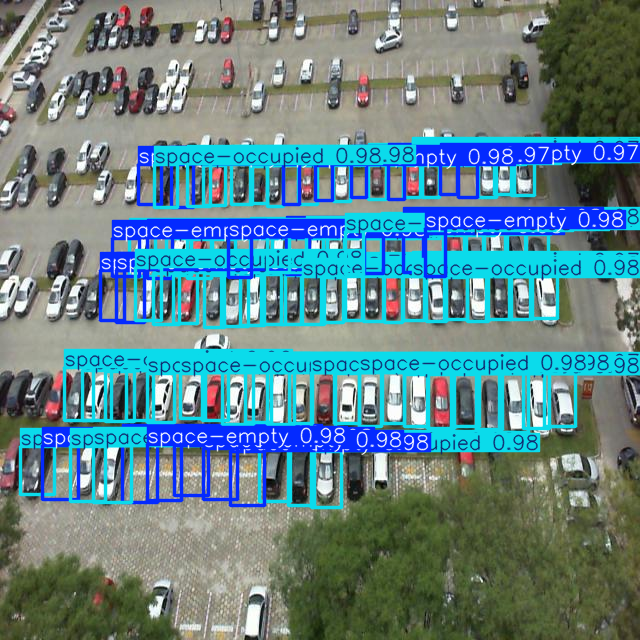

Object counts per class:
space-empty: 23
space-occupied: 77


In [12]:
#output an image in the test dataset with prediction boxes and space counts, from the orignial file path

#this can be a single image or a list
results = best_model("/content/drive/MyDrive/580F Project/PKLot/test/2012-11-06_13_58_32_jpg.rf.d129d29b02996f4ae3b3910a83b77cbb.jpg")
class_counts = {}

for result in results:
  #get annotation and prediction info
    boxes = result.boxes
    masks = result.masks
    keypoints = result.keypoints
    probs = result.probs
    obb = result.obb
    result.show()

    #count number of each spot type
    class_ids = result.boxes.cls.tolist()
    names = result.names

    for class_id in class_ids:
        class_name = names[class_id]
        if class_name in class_counts:
            class_counts[class_name] += 1
        else:
            class_counts[class_name] = 1

#print results
print("Object counts per class:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

In [13]:
#scrape datetime from image file
def get_time_from_file(name):
    #remove non-date info from filename
    try:
        date_str = name.split('_jpg')[0]
        #create datetime object
        return datetime.datetime.strptime(date_str, '%Y-%m-%d_%H_%M_%S')
    except:
        return None

#similarly, find a file path from timestamp:

def get_image_path_from_datetime(target_datetime, annotations_dict, root_path):
    for img_info in annotations_dict['images']:
        file_name = img_info['file_name']
        image_datetime = get_time_from_file(file_name)
        if image_datetime == target_datetime:
            return os.path.join(root_path, file_name)
    return None

Found image: /content/drive/MyDrive/580F Project/PKLot/test/2013-03-18_07_20_01_jpg.rf.cf29f82fd8d753275d4b6ab5cfdbfcea.jpg


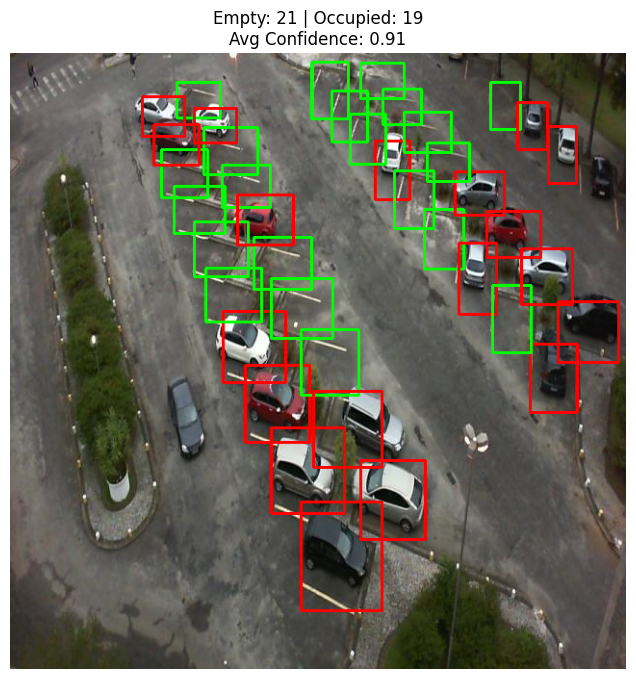

In [20]:
#use datetime (or full file path) to display predictions over an image
#2013-03-20 17:10:12
#2013-03-18 7:20:01
target_dt = datetime.datetime(2013, 3, 18, 7, 20, 1)
image_path = get_image_path_from_datetime(target_dt, test_annotations, TEST_PATH)

#output the image with prediction boxes
if image_path:
    print(f"Found image: {image_path}")
    results = best_model(image_path, imgsz=480, conf=0.3, verbose=False)

    #annotate image
    avg_conf, img_with_boxes, empty_cnt, occ_cnt = draw_yolo_results(results, image_path)

    #display
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB))
    plt.title(f"Empty: {empty_cnt} | Occupied: {occ_cnt}\nAvg Confidence: {avg_conf:.2f}")
    plt.axis("off")
    plt.show()
else:
    print(f"No image found for the specified date and time: {target_dt}")

### Dashboard Creation
Columns: Timestamp, day of week, lot name, number of empty spots, occupied spots, maximum spots.

In [ ]:
final_data = None #clears
final_data = pd.DataFrame(columns=['timestamp', 'day', 'emptyspots', 'maxspots', 'lot'])

#get directory
test_images_dir = "/content/working/custom_yolo_data/test/images"
image_filenames = os.listdir(test_images_dir)

empty_counts = []
timestamps = []
day = []
maxspots = []
lot = []

for file in image_filenames:
    full_image_path = os.path.join(test_images_dir, file)
    results = best_model(full_image_path, imgsz=480, conf=0.3, verbose=False)

    #count empty spaces
    empty_image_count = 0
    if results:
        result = results[0]
        class_ids = result.boxes.cls.tolist()
        names = result.names

        for class_id in class_ids:
            class_name = names[class_id]
            if class_name == 'space-empty':
                empty_image_count += 1

    empty_counts.append(empty_image_count)

    #get max # spaces and lot name
    if file.startswith("2012-11"):
      maxspots.append(100)
      lot.append("A")

    elif file.startswith("2012-12"):
      maxspots.append(28)
      lot.append("B")

    elif file.startswith("2013-03"):
      maxspots.append(40)
      lot.append("C")
    else:
      print(f"Error in assigning lot value for {file}.")

    #step 3: get timestamp + day of week
    time = get_time_from_file(file)
    timestamps.append(time)
    day.append(time.strftime("%A"))

#insert data into df
final_data['timestamp'] = timestamps
final_data['day'] = day
final_data['emptyspots'] = empty_counts
final_data['maxspots'] = maxspots
final_data['lot'] = lot



In [ ]:
#this ensures that empty + occupied will always equal the max
final_data["occupiedspots"] = final_data["maxspots"] - final_data["emptyspots"]
final_data["time"] = final_data["timestamp"].apply(lambda x: x.strftime("%H:%M:%S"))
final_data["date"] = final_data["timestamp"].apply(lambda x: x.strftime("%Y-%m-%d"))

In [ ]:
final_data.head(10)

,timestamp,day,emptyspots,maxspots,lot,occupiedspots,time,date
0,2013-03-16 14:10:09,Saturday,34,40,C,6,14:10:09,2013-03-16
1,2012-11-07 15:24:43,Wednesday,18,100,A,82,15:24:43,2012-11-07
2,2012-12-13 16:20:12,Thursday,0,28,B,28,16:20:12,2012-12-13
3,2012-12-29 12:55:35,Saturday,28,28,B,0,12:55:35,2012-12-29
4,2013-03-20 07:20:01,Wednesday,25,40,C,15,07:20:01,2013-03-20
5,2012-12-08 14:30:10,Saturday,28,28,B,0,14:30:10,2012-12-08
6,2013-03-12 17:25:13,Tuesday,0,40,C,40,17:25:13,2013-03-12
7,2012-12-26 09:15:04,Wednesday,28,28,B,0,09:15:04,2012-12-26
8,2012-12-25 10:15:05,Tuesday,29,28,B,-1,10:15:05,2012-12-25
9,2012-12-18 11:10:06,Tuesday,0,28,B,28,11:10:06,2012-12-18


In [ ]:
#issue: when model reads background spots incorrectly, we can end up with negative occupied spots
#similarly, can end up with more than the max number of spots

#normalize data accordingly:
final_data.loc[final_data['occupiedspots'] < 0, 'occupiedspots'] = 0
final_data.loc[final_data['emptyspots'] > final_data['maxspots'], 'emptyspots'] = final_data['maxspots']

In [ ]:
#export df
final_data.to_csv('Lot_Occupancy_PredictionsNEW.csv', index=False)